In [2]:
pip install pytrends

Note: you may need to restart the kernel to use updated packages.


In [14]:
import pandas as pd
from pytrends.request import TrendReq
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
Trending_topics = TrendReq(hl= 'en-US', tz=360)

### Build Payload

Now, we will create a data frame of the top 10 countries that search for the term "Data Analyst". For this, we will be using the method build_payload, which allows storing a list of keywords that you want to search. In this, you can also specify the timeframe and the categoryy to query the data from.

In [15]:
kw_list= ["ML Engineer"]
Trending_topics.build_payload(kw_list,cat=0, timeframe='now 7-d')

### Interest over time

This method, returns the historical, indexed data for when the specified keyword was most searched according to the timeframe mentioned in the build payload method.

In [16]:
Trending_topics.build_payload(kw_list=["ML Engineer"], cat=0, timeframe='now 7-d')
data = Trending_topics.interest_over_time()
data = data.sort_values(by="ML Engineer", ascending = False)
data= data.head(10)
print(data)

                     ML Engineer  isPartial
date                                       
2026-02-12 02:00:00          100      False
2026-02-11 16:00:00           72      False
2026-02-07 04:00:00           65      False
2026-02-07 06:00:00           64      False
2026-02-10 09:00:00           60      False
2026-02-06 19:00:00           59      False
2026-02-09 22:00:00           56      False
2026-02-06 23:00:00           55      False
2026-02-10 03:00:00           54      False
2026-02-07 07:00:00           53      False


### Historical Hour Interest

The get_historical_interest() method returns the historical, indexed, hourly data for when the specified keyword was most searched. You can also mention various time period parameters for which you want the hostorical data such as year_start, month_start, hour_start, year_end, month_end, day_end, and hour_end.

In [17]:
data = Trending_topics.interest_by_region() 
data = data.sort_values(by="ML Engineer",ascending = False) 
data = data.head(10) 
print(data)

               ML Engineer
geoName                   
Armenia                100
India                   87
Sri Lanka               70
Nepal                   60
Pakistan                42
Singapore               40
Canada                  37
United States           35
Kazakhstan              30
Bangladesh              30


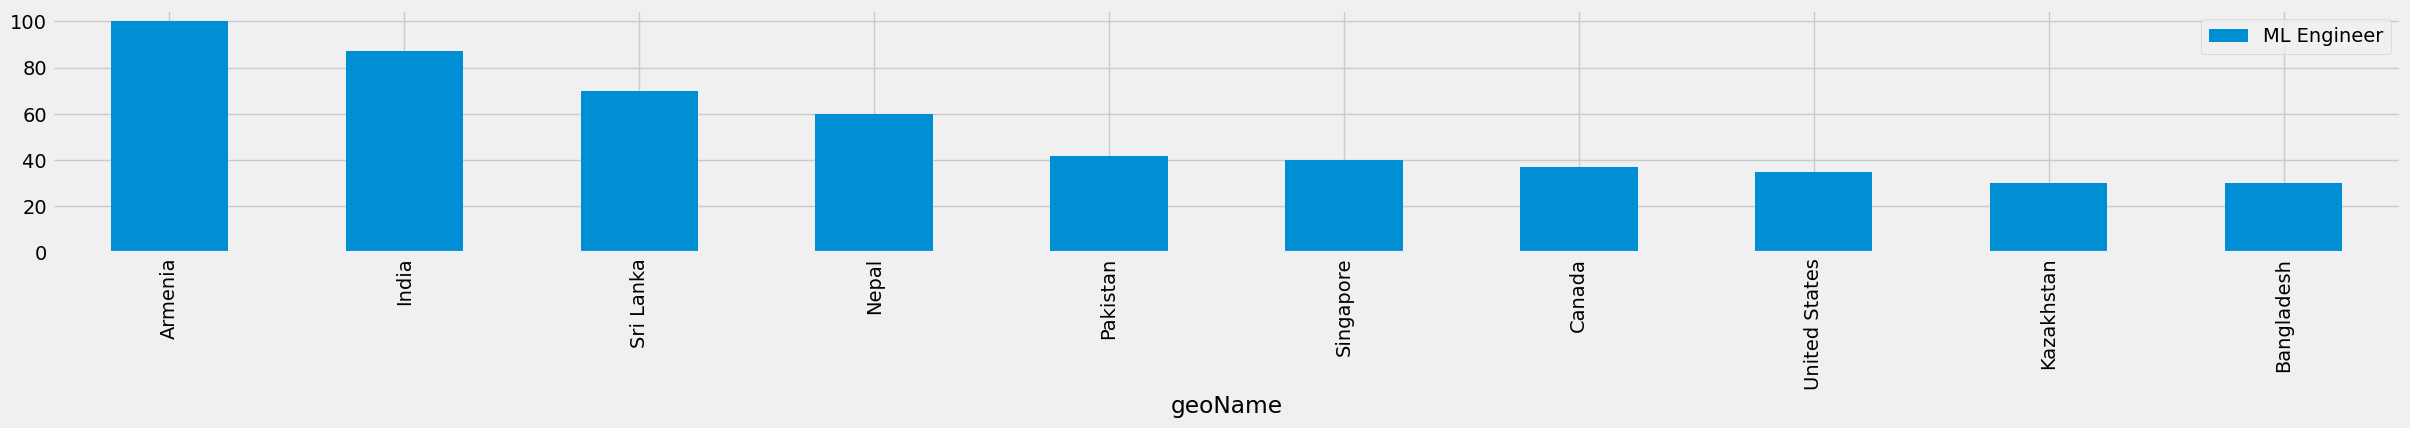

In [18]:
data.reset_index().plot(x= 'geoName', y='ML Engineer', figsize=(27,3), kind='bar')
plt.style.use('fivethirtyeight')
plt.show()

### Related Queries

Whenever a user searches for something about a particular topic on google there is a high probability that the user will search for more queries related to the same topic. These are known as related queries. Let us find a list of related queries for "Fire Safety"

In [22]:
Trending_topics.build_payload(kw_list=['Machine Learning Engineer'])
related_queries= Trending_topics.related_queries()
related_queries.values()

dict_values([{'top':                               query  value
0                     data engineer    100
1  senior machine learning engineer     26
2                      data science     25, 'rising':                               query  value
0  senior machine learning engineer     80}])